In [1]:
print("Day 2 start")

Day 2 start


In [3]:
import yfinance as yf

raw = yf.download("SPY", start="2025-01-01", end="2026-01-01")
data = raw.droplevel('Ticker', axis=1)

print(data.columns)

[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [4]:
print(data.describe())

Price       Close        High         Low        Open        Volume
count  250.000000  250.000000  250.000000  250.000000  2.500000e+02
mean   614.198195  617.339556  610.341542  614.023397  7.244500e+07
std     47.447118   46.415343   48.741464   47.790473  2.913371e+07
min    490.853088  515.787256  476.339470  483.645729  2.604870e+07
25%    581.479218  585.548369  577.135426  581.219633  5.766440e+07
50%    615.345520  617.829420  612.762374  616.669314  6.812535e+07
75%    658.778961  662.042848  654.944412  658.547755  8.113838e+07
max    688.499695  689.776169  687.392725  688.758989  2.566114e+08


In [5]:
print(data["Close"].describe())

count    250.000000
mean     614.198195
std       47.447118
min      490.853088
25%      581.479218
50%      615.345520
75%      658.778961
max      688.499695
Name: Close, dtype: float64


In [7]:
daily_return = data["Close"].pct_change()
print(daily_return.describe())

count    249.000000
mean       0.000740
std        0.012299
min       -0.058543
25%       -0.003564
50%        0.001376
75%        0.005761
max        0.105019
Name: Close, dtype: float64


In [11]:
best_day = daily_return.idxmax()
worst_day = daily_return.idxmin()

best_return = daily_return[best_day]
worst_return = daily_return[worst_day]

print(f"Best Day: {best_day.date()} -- Daily_Return: {best_return:.2%}")
print(f"Worst Day: {worst_day.date()} -- Daily_Return: {worst_return:.2%}")

Best Day: 2025-04-09 -- Daily_Return: 10.50%
Worst Day: 2025-04-04 -- Daily_Return: -5.85%


In [13]:
data['cumulative_return'] = (1 + daily_return).cumprod()
print(data['cumulative_return'].tail())

2025-12-24    1.194731
2025-12-26    1.194609
2025-12-29    1.190352
2025-12-30    1.188899
2025-12-31    1.180090
Name: cumulative_return, dtype: float64


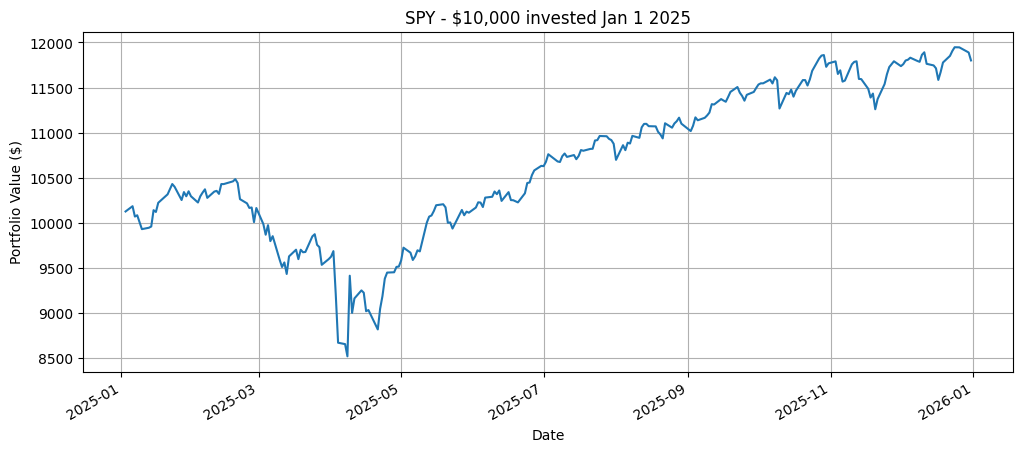

In [14]:
import matplotlib.pyplot as plt

(data['cumulative_return']*10000).plot(figsize=(12,5))
plt.title("SPY - $10,000 invested Jan 1 2025")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [15]:
print(daily_return.head())

2025-01-02         NaN
2025-01-03    0.012503
2025-01-06    0.005761
2025-01-07   -0.011304
2025-01-08    0.001461
Name: Close, dtype: float64
